# Assessing Learnability: Multi-Year Dataset

## Notebook Outline

1. Load and merge salary, player statistics, and team data for 2021-2025
2. Check basic signal, sample size, and feature-target alignment
3. Compare Dummy, Linear Regression, and Random Forest models
4. Review domain and technical limitations
5. Summarize learnability and next steps

## 1. Data Loading & Integration

Load all raw CSV files from 2021 through 2025, merge player salary with player production within each season, attach team context, and combine the season-level modeling datasets into one multi-year dataframe.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

In [2]:
# Load and integrate data
repo = Path.cwd().parent
data_dir = repo / "data" / "raw"
years = list(range(2021, 2026))

# Load raw CSV components
raw = {}
for year in years:
    raw[year] = {
        "advanced": pd.read_csv(data_dir / f"{year}_advanced.csv"),
        "per_game": pd.read_csv(data_dir / f"{year}_per_game.csv"),
        "totals": pd.read_csv(data_dir / f"{year}_totals.csv"),
        "salary": pd.read_csv(data_dir / f"salary_{year}.csv"),
        "team_advanced": pd.read_csv(data_dir / f"{year}_advanced-team.csv"),
        "standings": pd.read_csv(data_dir / f"{year}_wnba_standings.csv"),
    }

for year, files in raw.items():
    print(f"\n{year}")
    for name, df in files.items():
        print(f"{name}: {df.shape}")


2021
advanced: (155, 24)
per_game: (155, 27)
totals: (155, 26)
salary: (191, 27)
team_advanced: (12, 27)
standings: (12, 5)

2022
advanced: (166, 24)
per_game: (166, 27)
totals: (166, 26)
salary: (202, 27)
team_advanced: (12, 27)
standings: (12, 5)

2023
advanced: (156, 24)
per_game: (156, 27)
totals: (156, 26)
salary: (184, 27)
team_advanced: (12, 27)
standings: (12, 5)

2024
advanced: (157, 24)
per_game: (157, 27)
totals: (157, 26)
salary: (180, 27)
team_advanced: (12, 27)
standings: (12, 5)

2025
advanced: (182, 24)
per_game: (182, 27)
totals: (182, 26)
salary: (227, 27)
team_advanced: (13, 27)
standings: (13, 5)


### Basic Cleaning

Before merging the datasets, standardize column names and clean simple text values.

For example, column names like `2021 Salary`, `2025 Salary`, and `FG%` are converted to simpler formats such as `salary` and `fgpct`. The salary column is also converted to numeric format because it will be used as the regression target.

In [3]:
# Standardize column names into a code-friendly format
def clean_col(name):
    text = str(name).strip().lower()
    text = re.sub(r"20\d{2}\s+salary", "salary", text)
    text = re.sub(r"20\d{2}\s+signing", "signing", text)
    text = text.replace("%", "pct")

    # Replace spaces and symbols with underscores
    text = re.sub(r"[^0-9a-z]+", "_", text)
    text = text.strip("_")
    return text

# Apply basic cleaning to one dataframe
def clean_df(df):
    df = df.copy()

    # Apply the same column-name format to each dataset
    df.columns = [clean_col(col) for col in df.columns]

    # Clean text columns by removing extra spaces and standardizing missing values
    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"": np.nan, "—": np.nan, "nan": np.nan})

    return df

cleaned = {}
for year, files in raw.items():
    cleaned[year] = {name: clean_df(df) for name, df in files.items()}
    cleaned[year]["salary"]["salary"] = pd.to_numeric(cleaned[year]["salary"]["salary"], errors="coerce")

### Final Data Merge and Name Matching

In this step, create the final modeling dataframe by combining player production, salary, and team-level data for each season.

The merge process has three main parts:

1. Align team names  
   The team-level files use full team names, while the player-level files use team abbreviations. Mapping full team names to abbreviations so the team data can be merged with player data.

2. Combine player production data  
   Merge per-game, advanced, and total-count player statistics into one player-level production dataframe for each season.

3. Match player names before the final merge  
   Before merging salary data with production data, check which players appear only in the salary file or only in the production tables. Some differences come from encoding issues or slightly different name formats, so manually correct clear mismatches before creating the final dataset.

The final dataframe is created with an inner merge inside each season, meaning it keeps only player-season rows that have both salary data and on-court production data. Players appearing only in the salary file are excluded because they do not have usable same-season production statistics for this modeling task.

In [4]:
# Map full team names from team-level files to the abbreviations used in player-level files
teammap = {
    "Atlanta Dream": "ATL",
    "Chicago Sky": "CHI",
    "Connecticut Sun": "CON",
    "Dallas Wings": "DAL",
    "Golden State Valkyries": "GSV",
    "Indiana Fever": "IND",
    "Las Vegas Aces": "LVA",
    "Los Angeles Sparks": "LAS",
    "Minnesota Lynx": "MIN",
    "New York Liberty": "NYL",
    "Phoenix Mercury": "PHO",
    "Seattle Storm": "SEA",
    "Washington Mystics": "WAS",
}

def team_clean(val):
    if pd.isna(val):
        return np.nan

    # Basketball Reference marks some teams with "*"; remove it before mapping
    return str(val).replace("*", "").strip()

season_parts = {}

for year in years:
    adv = cleaned[year]["advanced"]
    per = cleaned[year]["per_game"]
    tot = cleaned[year]["totals"]
    sal = cleaned[year]["salary"].copy()
    teamadv = cleaned[year]["team_advanced"].copy()
    stand = cleaned[year]["standings"].copy()

    # Standardize team names so team-level data can merge with player-level data
    teamadv["team_name"] = teamadv["team"].map(team_clean)
    teamadv["team"] = teamadv["team_name"].map(teammap)
    stand["team_name"] = stand["team_name"].map(team_clean)
    stand["team"] = stand["team_name"].map(teammap)

    # Combine team advanced stats with standings data
    teamdf = teamadv.merge(stand, on=["team", "team_name"], how="left", suffixes=("_adv", "_stand"))

    # Merge per_game and advanced player stats into one production dataframe
    playerdf = per.merge(adv, on=["player", "team", "pos", "g", "mp"], how="outer", suffixes=("_per", "_adv"))
    # Add total count stats to the same player production dataframe.
    playerdf = playerdf.merge(tot, on=["player", "team", "pos", "g", "mp", "gs"], how="outer", suffixes=("", "_tot"))

    # Check player name mismatches before creating final_df
    salary_only = sal[~sal["player"].isin(playerdf["player"])]
    stats_only = playerdf[~playerdf["player"].isin(sal["player"])]

    print(f"\n{year} Before name fixes")
    print("Salary only players:")
    print(sorted(salary_only["player"].dropna().unique()))

    print("\nStats only players:")
    print(sorted(stats_only["player"].dropna().unique()))

    # Save the season-level intermediate dataframes so they can be reused
    season_parts[year] = {
        "sal": sal,
        "playerdf": playerdf,
        "teamdf": teamdf,
    }


2021 Before name fixes
Salary only players:
['Brittany Boyd-Jones', 'Jocelyn Willoughby', 'Maria Kliundikova', "N'Dea Jones", 'Rennia Davis']

Stats only players:
['Brittany Boyd']

2022 Before name fixes
Salary only players:
['Asia (AD) Durr', 'Brittney Griner', 'Kia Nurse']

Stats only players:
['AD Durr']

2023 Before name fixes
Salary only players:
['Asia (AD) Durr', 'Azurá Stevens', 'Christyn Williams', 'Diamond DeShields', 'Dorka Juhász', 'Isabelle Harrison', 'Ivana Dojkić', 'Katie Lou Samuelson', 'Lou Lopez Sénéchal', 'Natalie Achonwa', 'Riquna Williams', 'Sika Koné', 'Skylar Diggins']

Stats only players:
['AD Durr', 'Azura Stevens', 'Dorka JuhÃ¡sz', 'Ivana DojkiÄ\x87', 'Kadi Sissoko', 'Sika KonÃ©']

2024 Before name fixes
Salary only players:
['Dorka Juhász', 'Ivana Dojkić', 'Lou Lopez Sénéchal', 'Nika Mühl', 'Olivia Époupa', 'Sika Kone', 'Temi Fágbénlé']

Stats only players:
['Dorka JuhÃ¡sz', 'Ivana DojkiÄ\x87', 'Lou Lopez SÃ©nÃ©chal', 'Nika MÃ¼hl', 'Olivia Ã\x89poupa', 'Sik

In [5]:
# Manually fix clear name encoding/spelling mismatches across the 2021-2025 files
name_fix = {
    "AD Durr": "Asia (AD) Durr",
    "Anastasiia Kosu": "Anastasiia Olairi Kosu",
    "Azura Stevens": "Azura Stevens",
    "Azurá Stevens": "Azura Stevens",
    "Brittany Boyd": "Brittany Boyd-Jones",
    "Dorka JuhÃ¡sz": "Dorka Juhasz",
    "Dorka Juhász": "Dorka Juhasz",
    "Ivana DojkiÄ": "Ivana Dojkic",
    "Ivana Dojkić": "Ivana Dojkic",
    "Janelle SalaÃ¼n": "Janelle Salaun",
    "Janelle Salaün": "Janelle Salaun",
    "LeÃ¯la Lacan": "Leila Lacan",
    "Leïla Lacan": "Leila Lacan",
    "Lou Lopez SÃ©nÃ©chal": "Lou Lopez Senechal",
    "Lou Lopez Sénéchal": "Lou Lopez Senechal",
    "Luisa GeiselsÃ¶der": "Luisa Geiselsoder",
    "Luisa Geiselsöder": "Luisa Geiselsoder",
    "Mamignan TourÃ©": "Mamignan Toure",
    "Mamignan Touré": "Mamignan Toure",
    "MariÃ¨me Badiane": "Marieme Badiane",
    "Marième Badiane": "Marieme Badiane",
    "Nika MÃ¼hl": "Nika Muhl",
    "Nika Mühl": "Nika Muhl",
    "Olivia Ãpoupa": "Olivia Epoupa",
    "Olivia Époupa": "Olivia Epoupa",
    "Sika KonÃ©": "Sika Kone",
    "Sika Koné": "Sika Kone",
    "Te-Hina PaoPao": "Te-Hina Paopao",
    "Temi Fágbénlé": "Temi Fagbenle",
}

season_dfs = []

for year in years:
    # Retrieve the saved season-level dataframes for applying name fixes and final merging
    sal = season_parts[year]["sal"].copy()
    playerdf = season_parts[year]["playerdf"].copy()
    teamdf = season_parts[year]["teamdf"]

    # Apply the name corrections before merging salary and production data
    sal["player"] = sal["player"].replace(name_fix)
    playerdf["player"] = playerdf["player"].replace(name_fix)

    # Re-check after name fixes
    salary_only = sal[~sal["player"].isin(playerdf["player"])]
    stats_only = playerdf[~playerdf["player"].isin(sal["player"])]

    print(f"\n{year} After name fixes")
    print("Salary only players:")
    print(sorted(salary_only["player"].dropna().unique()))

    print("\nStats only players:")
    print(sorted(stats_only["player"].dropna().unique()))

    # seasondf = salary + player stats + team context + season column
    seasondf = sal.merge(playerdf, on="player", how="inner", suffixes=("_sal", ""))
    seasondf = seasondf.merge(teamdf, on="team", how="left", suffixes=("", "_team"))
    seasondf["season"] = year

    # season_dfs = [seasondf_2021, seasondf_2022, seasondf_2023, seasondf_2024, seasondf_2025]
    season_dfs.append(seasondf)

final_df = pd.concat(season_dfs, ignore_index=True)

print(final_df.shape)
final_df.head()


2021 After name fixes
Salary only players:
['Jocelyn Willoughby', 'Maria Kliundikova', "N'Dea Jones", 'Rennia Davis']

Stats only players:
[]

2022 After name fixes
Salary only players:
['Brittney Griner', 'Kia Nurse']

Stats only players:
[]

2023 After name fixes
Salary only players:
['Christyn Williams', 'Diamond DeShields', 'Isabelle Harrison', 'Katie Lou Samuelson', 'Lou Lopez Senechal', 'Natalie Achonwa', 'Riquna Williams', 'Skylar Diggins']

Stats only players:
['Kadi Sissoko']

2024 After name fixes
Salary only players:
[]

Stats only players:
[]

2025 After name fixes
Salary only players:
['Georgia Amoore', 'Katie Lou Samuelson']

Stats only players:
[]
(967, 124)


,player,salary,signing,g_sal,gs_sal,min,pts_sal,fgm,fga_sal,fgpct,...,opp_tov_pct,drb_pct,opp_ft_rate,arena_name,team_name,wins_stand,losses_stand,win_loss_pct,gb,season
0,Tina Charles,175000,UFA,27,27,33.3,23.4,8.8,19.6,44.9%,...,15.3,76.4,0.208,St. Elizabeths East Arena,Washington Mystics,12.0,20.0,0.375,14.0,2021
1,Brittney Griner,221450,NaN,30,30,32.8,20.5,8.3,14.4,57.5%,...,11.3,75.1,0.167,Phoenix Suns Arena,Phoenix Mercury,19.0,13.0,0.594,7.0,2021
2,Breanna Stewart,190550,NaN,28,28,33.3,20.3,6.9,15.8,43.9%,...,14.4,78.6,0.180,Angels of the Winds Arena,Seattle Storm,21.0,11.0,0.656,5.0,2021
3,Jonquel Jones,190550,NaN,27,27,31.7,19.4,7.1,13.8,51.5%,...,16.1,82.1,0.201,Mohegan Sun Arena,Connecticut Sun,26.0,6.0,0.813,NaN,2021
4,Arike Ogunbowale,58710,NaN,32,32,31.4,18.7,6.2,16.3,38.3%,...,14.1,77.6,0.206,College Park Center,Dallas Wings,14.0,18.0,0.438,12.0,2021


## 2. Preliminary Learnability Checks

This section checks whether the merged multi-year dataset is reasonable for a basic machine learning test.
> Focus on three quick checks: signal, sample size, and feature-target alignment.

### Signal Check

Before fitting models, check whether major on-court production statistics have some relationship with salary.

In [6]:
# Check simple correlations between salary and selected production indicators
checkcols = ["salary", "per", "pts_per_g", "ws", "mp_per_g", "usg_pct", "ast_per_g", "trb_per_g", "season"]
checkcols = [col for col in checkcols if col in final_df.columns]

corr = final_df[checkcols].corr(numeric_only=True)["salary"].drop("salary", errors="ignore")
print("Correlation with salary:")
print(corr.sort_values(key=lambda x: x.abs(), ascending=False))

Correlation with salary:
pts_per_g    0.677222
mp_per_g     0.655505
ws           0.581032
ast_per_g    0.518031
trb_per_g    0.517990
per          0.495883
usg_pct      0.421641
season       0.025121
Name: salary, dtype: float64


In [7]:
print("final_df shape:", final_df.shape)
print("rows with salary:", final_df["salary"].notna().sum())    #  Number of rows with target values
print("unique players:", final_df["player"].nunique())      # Number of players after removing duplicates
print("unique player-season rows:", final_df[["player", "season"]].drop_duplicates().shape[0])  # Number of player-season combinations
print("unique seasons:", final_df["season"].nunique())  #  Number of included seasons
print("unique teams:", final_df["team"].nunique())      #  Number of teams appearing in the data
# Number of rows where team-level information was not merged => TOT
print("rows with missing team context:", final_df["team_name"].isna().sum())    

final_df shape: (967, 124)
rows with salary: 967
unique players: 313
unique player-season rows: 815
unique seasons: 5
unique teams: 14
rows with missing team context: 172


## 3. Back-of-the-Envelope Modeling Test

Modeling test to see whether the current multi-year features can predict salary better than a trivial baseline.

Setup:
- `x`: model input features
- `y`: target variable, salary

Some columns are removed before modeling:
- `salary`: the target variable, so it cannot be used as a feature
- `player`: player names can cause the model to memorize individuals rather than learn general patterns
- `team_name`: duplicates the team column
- `arena_name`: mostly overlaps with team information and is not directly related to player salary
- `dummy`, `dummy_team`: empty placeholder columns from the source tables

For preprocessing, numeric missing values are filled with the median because the dataset is small and dropping rows would reduce the sample size. The median is also less sensitive to outliers than the mean. Categorical missing values are filled as `Unknown`, then converted with one-hot encoding so the models can use them.

The models tested are `DummyRegressor`, `LinearRegression`, and `RandomForestRegressor`, evaluated with 5-fold cross-validation using RMSE.

In [8]:
# Drop target, identifiers, and empty placeholder columns before modeling
dropcols = {"salary", "player", "team_name", "arena_name", "dummy", "dummy_team"}
xcols = [col for col in final_df.columns if col not in dropcols]

# Keep only rows with a salary value, since salary is the regression target
modeldf = final_df.dropna(subset=["salary"])

x = modeldf[xcols]
y = modeldf["salary"]

# Split features by data type so numeric and categorical columns can be processed differently
numcols = x.select_dtypes(include=np.number).columns.tolist()
catcols = x.select_dtypes(exclude=np.number).columns.tolist()

# Numeric features: fill missing values with the median and scale the values
numpipe = Pipeline([
    ("fill", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

# Categorical features: mark missing values as Unknown, convert mixed object columns to string, and one-hot encode categories
catpipe = Pipeline([
    ("fill", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("to_string", FunctionTransformer(lambda data: data.astype(str))),
    ("code", OneHotEncoder(handle_unknown="ignore"))
])

# Apply the numeric pipeline to numeric columns and the categorical pipeline to categorical columns
preproc = ColumnTransformer([
    ("num", numpipe, numcols),
    ("cat", catpipe, catcols)
])

# Define a trivial baseline, a simple linear model, and a tree-based model
models = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=26),
}

# Use 5-fold cross-validation and evaluate prediction error with RMSE
cv = KFold(n_splits=5, shuffle=True, random_state=26)
rmse = "neg_root_mean_squared_error"

### Cross-Validation Model Comparison

Evaluate each model with 5-fold cross-validation and summarize the RMSE for each fold.
> Question: Whether `LinearRegression` or `RandomForestRegressor` can predict salary better than `DummyRegressor` on the combined 2021-2025 dataset.

Since scikit-learn returns RMSE as a negative score, multiply the cross-validation scores by `-1` so the table reports positive RMSE values. Lower RMSE is better.

In [9]:
# Store cross-validation results for each model
rows = []
for name, mod in models.items():
    # Combine preprocessing and the model so each fold is processed consistently
    pipe = Pipeline([
        ("prep", preproc),
        ("model", mod)
    ])

    # cross_val_score returns negative RMSE, so multiply by -1 to report positive RMSE
    vals = -cross_val_score(pipe, x, y, cv=cv, scoring=rmse)
    rows.append({
        "model": name,
        "rmse_mean": vals.mean(),   # lower is better
        "rmse_std": vals.std(),     # larger values mean less stable performance across folds
        "fold_1": vals[0],          # RMSE from each validation fold
        "fold_2": vals[1],
        "fold_3": vals[2],
        "fold_4": vals[3],
        "fold_5": vals[4],
    })

# Convert model results into a comparison table
resdf = pd.DataFrame(rows)
# Use DummyRegressor as the baseline
base = resdf.loc[resdf["model"].eq("DummyRegressor"), "rmse_mean"].iloc[0]
# Positive gain means the model improves over the dummy baseline
resdf["gain"] = base - resdf["rmse_mean"]
# Sort by average RMSE so the best model appears first
resdf.sort_values("rmse_mean")

,model,rmse_mean,rmse_std,fold_1,fold_2,fold_3,fold_4,fold_5,gain
2,RandomForestRegressor,39807.932398,2454.587042,40348.195119,37153.462447,41694.457859,43020.320957,36823.225606,28338.280573
1,LinearRegression,55170.527665,5008.804599,56089.165388,50935.840260,49685.742518,55220.431894,63921.458265,12975.685305
0,DummyRegressor,68146.212970,2633.331335,65570.929343,66777.106344,73200.539297,67549.788708,67632.701158,0.000000


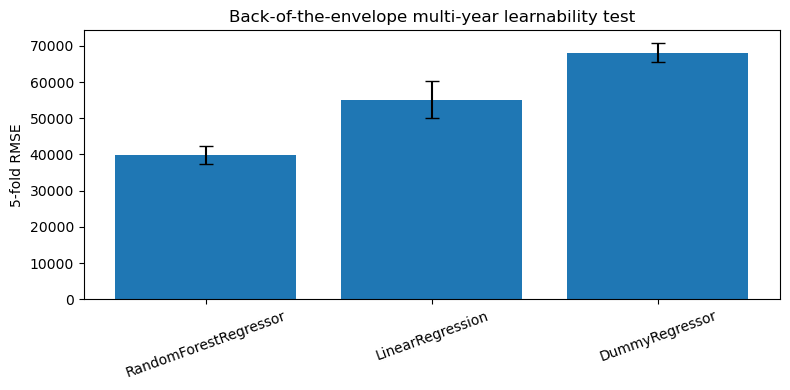

In [10]:
plotdf = resdf.sort_values("rmse_mean")
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(plotdf["model"], plotdf["rmse_mean"], yerr=plotdf["rmse_std"], capsize=5)
ax.set_ylabel("5-fold RMSE")
ax.set_title("Back-of-the-envelope multi-year learnability test")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Result Interpretation

The results suggest that the combined 2021-2025 dataset is learnable for a basic salary prediction task. The `DummyRegressor` produces an average RMSE of about 68.1K, while `LinearRegression` lowers the RMSE to about 55.2K and `RandomForestRegressor` lowers it further to about 39.8K.

The best model, `RandomForestRegressor`, improves RMSE by roughly 28.3K over the dummy baseline. The fold-level results also show that Random Forest is relatively stable across validation splits, with fold RMSE values ranging from about 36.8K to 43.0K and a standard deviation of about 2.5K. Linear Regression has a wider fold range, from about 49.7K to 63.9K, suggesting less stable performance.

This indicates that player production, team context, and season information contain meaningful signal for explaining salary. 

## 4. Domain & Technical Sanity Check

- **Institutional Constraints:** WNBA salaries are shaped by the CBA, max contract limits, rookie salary scales, free agency status, roster rules, and team salary-cap strategy. Because of these constraints, on-court production alone cannot fully explain salary.

- **Team Context Limitation:** Some rows have missing team-level features because `TOT` represents combined player totals across multiple teams rather than a real team. Since `TOT` is not in the team advanced or standings tables, those rows cannot receive matched team context.

- **Multi-Year Caveat:** Players can appear in multiple seasons, so random cross-validation can place the same player in both training and validation folds across different years. This is acceptable for a quick learnability check, but a stricter validation design should consider grouping by player to test how well the model generalizes beyond repeated player records.

## 5. Conclusion & Recommendations

The summary below reports the best model, the baseline RMSE, and the improvement over the dummy baseline.

In [11]:
best = resdf.sort_values("rmse_mean").iloc[0]
base = resdf.loc[resdf["model"].eq("DummyRegressor")].iloc[0]

print("Best model:", best["model"])
print("Best RMSE:", round(best["rmse_mean"], 2))
print("Dummy RMSE:", round(base["rmse_mean"], 2))
print("RMSE improvement:", round(best["gain"], 2))

Best model: RandomForestRegressor
Best RMSE: 39807.93
Dummy RMSE: 68146.21
RMSE improvement: 28338.28


The combined 2021-2025 dataset shows clear learnable signal for salary prediction. The best model, `RandomForestRegressor`, reaches an average RMSE of about 39.8K, compared with about 68.1K for the `DummyRegressor`, improving RMSE by roughly 28.3K.

This suggests that player production, season, and team-context features explain meaningful salary variation across the multi-year dataset. The result is strong
enough to support building a later valuation benchmark, though institutional salary rules and missing team context for `TOT` rows remain important limitations.